<a href="https://colab.research.google.com/github/Kashishkewat/python_practice/blob/main/day41_python.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Random forest and  Bias variance**

**Random Forest = many decision trees + bagging + random feature selection**

**Each tree:**

**Trains on different random rows (bootstrap sampling)**

**Uses different random features at splits**

**Gives its own prediction
Final output = average (regression) or majority vote (classification)**

#**Bias in Random Forest**

**Bias = error from overly simple assumptions**

**Decision trees alone usually have:**

**Low bias (they can fit complex patterns)**

**Random Forest:**

**Keeps bias low or slightly higher than a single deep tree**

**Why slightly higher? Because averaging many trees smooths extreme predictions**

##**So compared to one deep decision tree:**

Bias: ⬆ slightly

But still low overall

##**Think of it like:**

**Many opinions averaged → less extreme → a bit more general.**

#**Variance in Random Forest (this is the big win)**

**Variance = error from model sensitivity to training data**

#**Single decision tree:**

Very high variance

Small data change → completely different tree

#**Random Forest:**

**Each tree sees different data,Predictions are averaged,Errors cancel out**

#**Variance becomes much lower**

**This is why Random Forest is powerful — it stabilizes unstable trees.**

In [2]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_circles
import matplotlib.pyplot as plt

In [4]:
np.random.seed(42)
X,y=make_circles(n_samples=500,factor=0.1,noise=0.35,random_state=42)
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2)

In [5]:
X.shape

(500, 2)

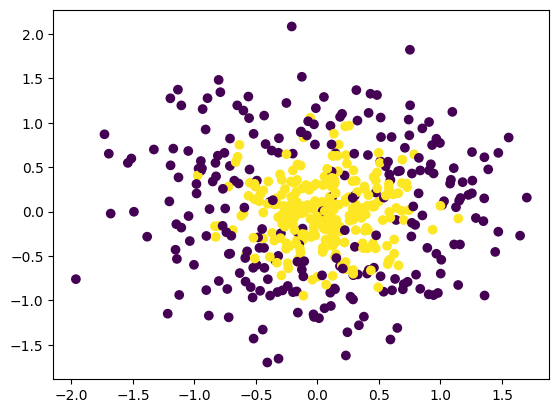

In [6]:
plt.scatter(X[:,0],X[:,1],c=y)

In [7]:
from sklearn.tree import DecisionTreeClassifier

In [8]:
dtree=DecisionTreeClassifier(random_state=42)
dtree.fit(X_train,y_train)

DecisionTreeClassifier(random_state=42)

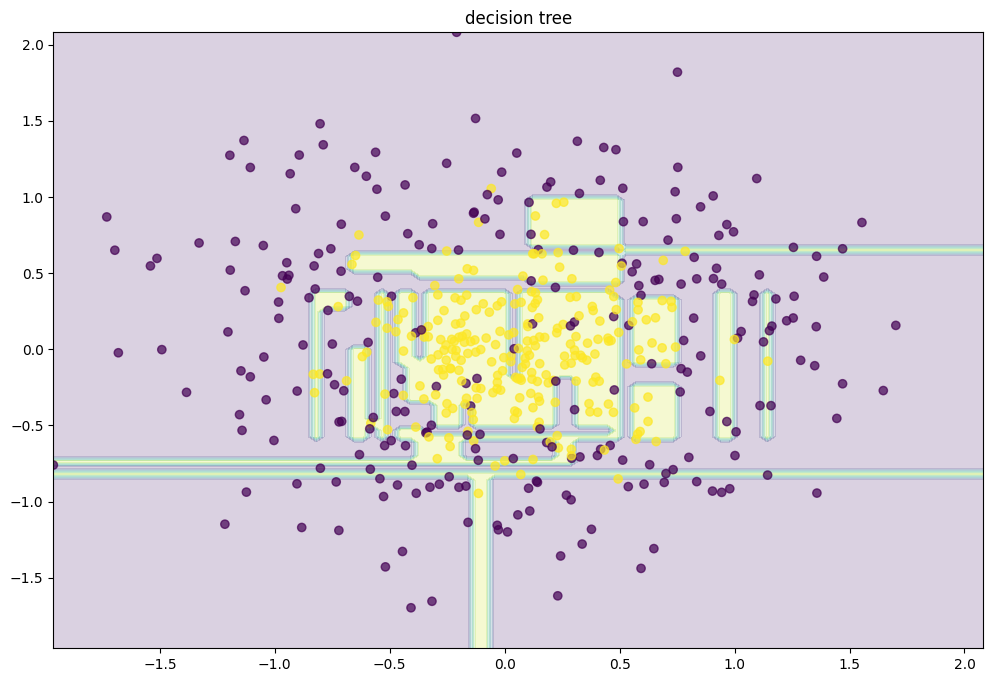

In [12]:
plt.figure(figsize=(12,8))
x_range=np.linspace(X.min(),X.max(),100)
xx1,xx2=np.meshgrid(x_range,x_range)
y_hat=dtree.predict(np.c_[xx1.ravel(),xx2.ravel()])
y_hat=y_hat.reshape(xx1.shape)
plt.contourf(xx1,xx2,y_hat,alpha=0.2)
plt.scatter(X[:,0],X[:,1],c=y,cmap="viridis",alpha=.7)
plt.title("decision tree")
plt.show()

In [13]:
from sklearn.ensemble import RandomForestClassifier

In [14]:
rf=RandomForestClassifier(n_estimators=500,random_state=42)
rf.fit(X_train,y_train)

RandomForestClassifier(n_estimators=500, random_state=42)

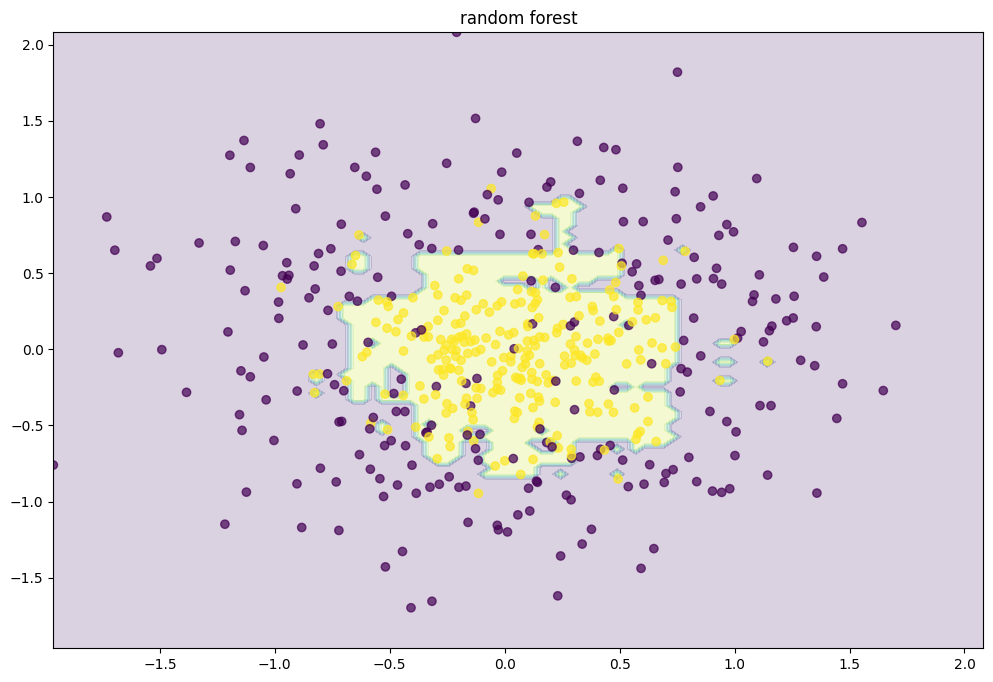

In [15]:
plt.figure(figsize=(12,8))
x_range=np.linspace(X.min(),X.max(),100)
xx1,xx2=np.meshgrid(x_range,x_range)
y_hat=rf.predict(np.c_[xx1.ravel(),xx2.ravel()])
y_hat=y_hat.reshape(xx1.shape)
plt.contourf(xx1,xx2,y_hat,alpha=0.2)
plt.scatter(X[:,0],X[:,1],c=y,cmap="viridis",alpha=.7)
plt.title("random forest")
plt.show()

In [16]:
n_train=150
n_test=1000
noise=0.1
# generate data
def f(x):
  x=x.ravel()
  return np.exp(-x**2)+1.5*np.exp(-(x-2)**2)
def generate(n_samples,noise):
  X=np.random.rand(n_samples)*10-5
  X=np.sort(X).ravel()
  y=np.exp(-X**2)+1.5*np.exp(-(X-2)**2)+np.random.normal(0.0,noise,n_samples)
  X=X.reshape((n_samples,1))
  return X,y
X_train,y_train=generate(n_samples=n_train,noise=noise)
X_test,y_test=generate(n_samples=n_test,noise=noise)


(-5.0, 5.0)

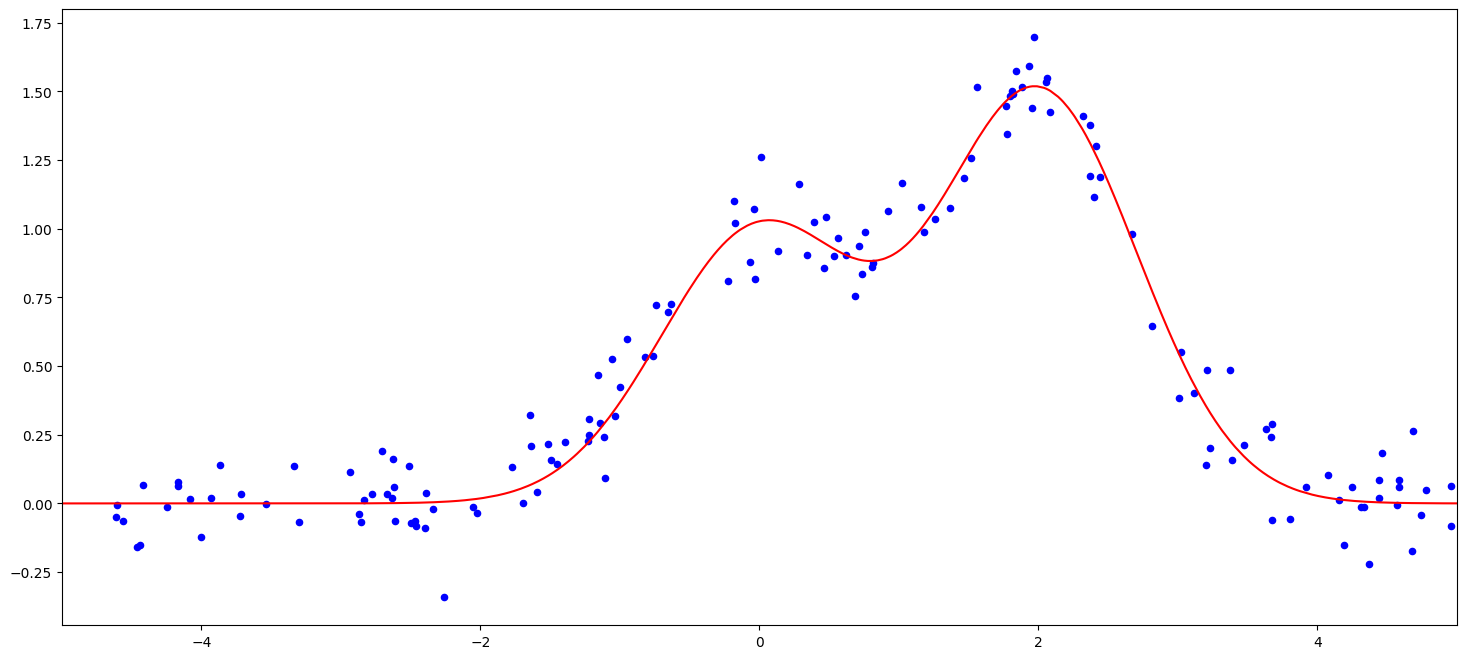

In [18]:
plt.figure(figsize=(18,8))
plt.plot(X_test,f(X_test),"r")
plt.scatter(X_train,y_train,color="b",s=20)
plt.xlim([-5,5])

Text(0.5, 1.0, 'Decision tree MSE=22.70')

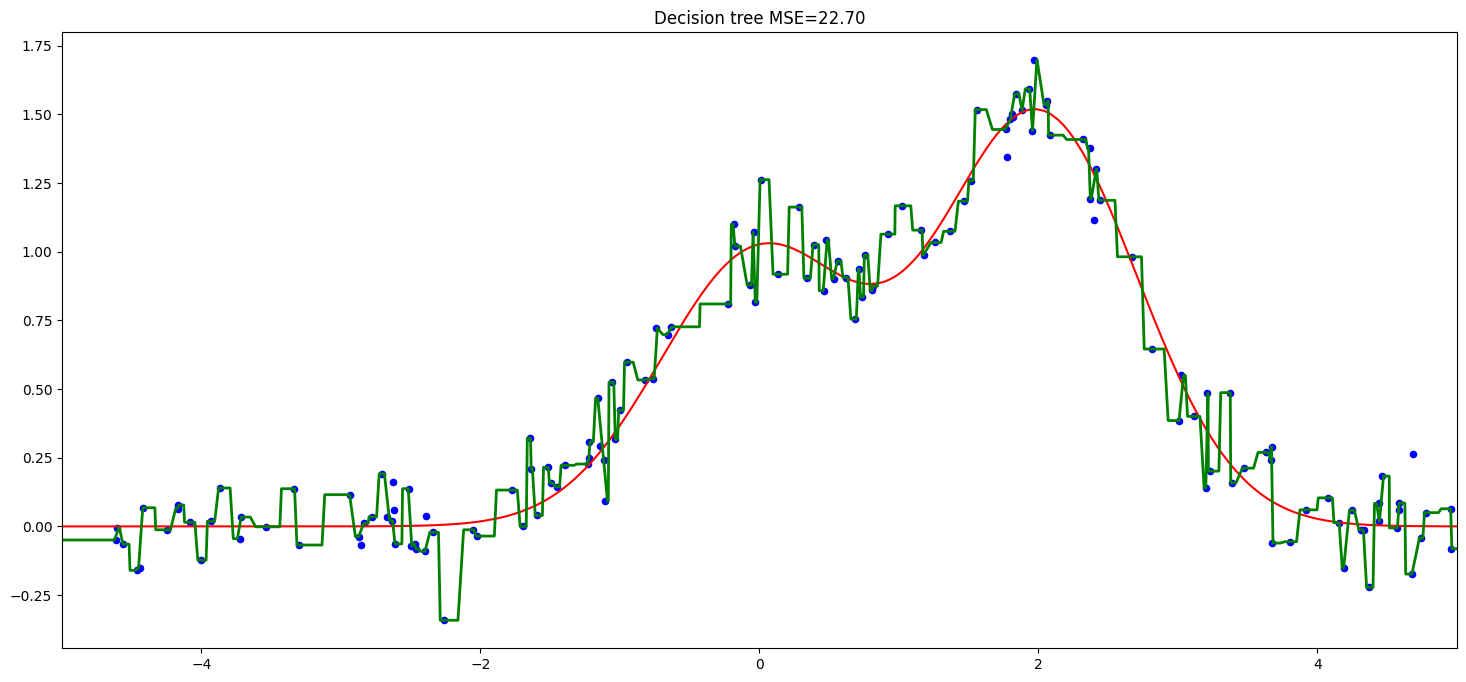

In [28]:
#one decision tree regressor
from sklearn.tree import DecisionTreeRegressor
dtree=DecisionTreeRegressor().fit(X_train,y_train)
d_predict=dtree.predict(X_test)
plt.figure(figsize=(18,8))
plt.plot(X_test,f(X_test),"r")
plt.scatter(X_train,y_train,color="b",s=20)
plt.plot(X_test,d_predict,"g",lw=2)
plt.xlim([-5,5])
plt.title("Decision tree MSE=%.2F"%np.sum((d_predict-y_test)**2))

In [23]:
from sklearn.ensemble import RandomForestRegressor

In [25]:
from sklearn.ensemble import RandomForestRegressor
rfr=RandomForestRegressor(n_estimators=1000)
rfr.fit(X_train,y_train)

RandomForestRegressor(n_estimators=1000)

In [26]:
rf_predict=rfr.predict(X_test)
print(rf_predict)

[-4.39468922e-02 -4.39468922e-02 -4.39468922e-02 -4.39468922e-02
 -4.39468922e-02 -4.39468922e-02 -4.39468922e-02 -4.39468922e-02
 -4.39468922e-02 -4.39468922e-02 -4.39468922e-02 -4.39468922e-02
 -4.39468922e-02 -4.39468922e-02 -4.39468922e-02 -4.39468922e-02
 -4.39468922e-02 -4.39468922e-02 -4.39468922e-02 -4.39468922e-02
 -4.39468922e-02 -4.39468922e-02 -4.39468922e-02 -4.39468922e-02
 -4.39468922e-02 -4.39468922e-02 -4.39468922e-02 -4.39468922e-02
 -4.39468922e-02 -4.39468922e-02 -4.39468922e-02 -4.39468922e-02
 -4.39468922e-02 -4.39468922e-02 -4.39468922e-02 -4.39468922e-02
 -4.39468922e-02 -2.61748786e-02 -2.83260101e-02 -5.19809635e-02
 -5.19809635e-02 -5.19809635e-02 -5.19809635e-02 -8.22600606e-02
 -9.23703327e-02 -1.25994895e-01 -1.32549714e-01 -1.32549714e-01
 -1.32549714e-01 -1.32549714e-01 -1.29082457e-01 -8.70816194e-03
 -8.70816194e-03 -7.33149215e-03 -7.33149215e-03  2.89265560e-03
  2.89265560e-03  2.32127344e-02 -9.04568739e-03 -6.04169126e-03
 -4.85124804e-03 -4.85124

Text(0.5, 1.0, 'random tree MSE=15.67')

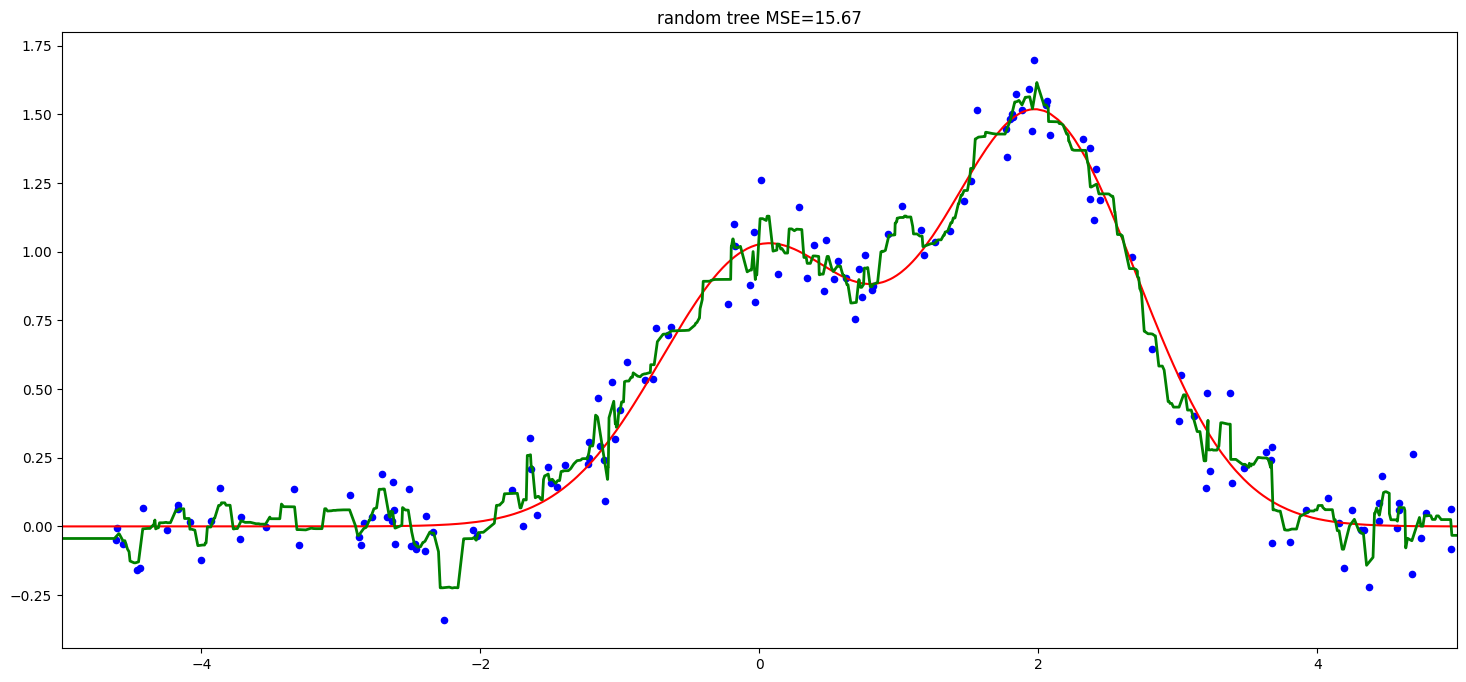

In [29]:
plt.figure(figsize=(18,8))
plt.plot(X_test,f(X_test),"r")
plt.scatter(X_train,y_train,color="b",s=20)
plt.plot(X_test,rf_predict,"g",lw=2)
plt.xlim([-5,5])
plt.title("random tree MSE=%.2F"%np.sum((y_test-rf_predict)**2))